In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

In [3]:
import os

# Create results directory in the notebook directory
os.makedirs("results", exist_ok=True)
print("Results directory created at:", os.path.abspath("results"))

Results directory created at: c:\Users\la7tim\Desktop\Internship\FedTinyProp\notebooks\results


In [4]:
import torchvision
import torchvision.transforms as transforms

# CIFAR-100 channel means and stds
C100_MEAN = (0.5071, 0.4865, 0.4409)
C100_STD  = (0.2673, 0.2564, 0.2762)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(C100_MEAN, C100_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(C100_MEAN, C100_STD),
])

# Load CIFAR-100
trainset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test)

# Print dataset info
print(f"Training set size: {len(trainset)}")   # → 50,000
print(f"Test set size:     {len(testset)}")    # → 10,000
print(f"Number of classes: {len(trainset.classes)}")  # → 100


Training set size: 50000
Test set size:     10000
Number of classes: 100


In [5]:
num_clients = 5
partitions = {
    "medium":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.5),   # Medium skew
    "noniid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),   # Low alpha -> non-IID
    
}


=== Partition Statistics for CIFAR-100 ===

MEDIUM Partition:
Total samples: 50000

Per-client distribution:
Client 0: 11846 samples (23.69%)
Client 1: 7000 samples (14.00%)
Client 2: 9700 samples (19.40%)
Client 3: 11190 samples (22.38%)
Client 4: 10264 samples (20.53%)

NONIID Partition:
Total samples: 50000

Per-client distribution:
Client 0: 8487 samples (16.97%)
Client 1: 8697 samples (17.39%)
Client 2: 10844 samples (21.69%)
Client 3: 10037 samples (20.07%)
Client 4: 11935 samples (23.87%)
[Debug] Number of classes: 100
[Debug] Number of clients: 5
[Debug] Processing client 0 with 11846 samples
[Debug] Client 0 has 11846 valid targets
[Debug] Client 0 class counts: [190. 114.   1.   3.  14.   1.  74.  20. 378.  52. 158.  35.  63.   2.
  24. 319.  69.   1.   1. 220.  27. 283.  47. 230. 212.  21.   1. 345.
 350.  33.   6.  81.   1.   1. 185. 307.  18.   1.  68.  45. 277.  93.
  17. 179.  28.   1.   3. 330.  16. 116.  96.  83. 220.  35. 418.   2.
  79. 254. 103.  94.  14. 281. 331.

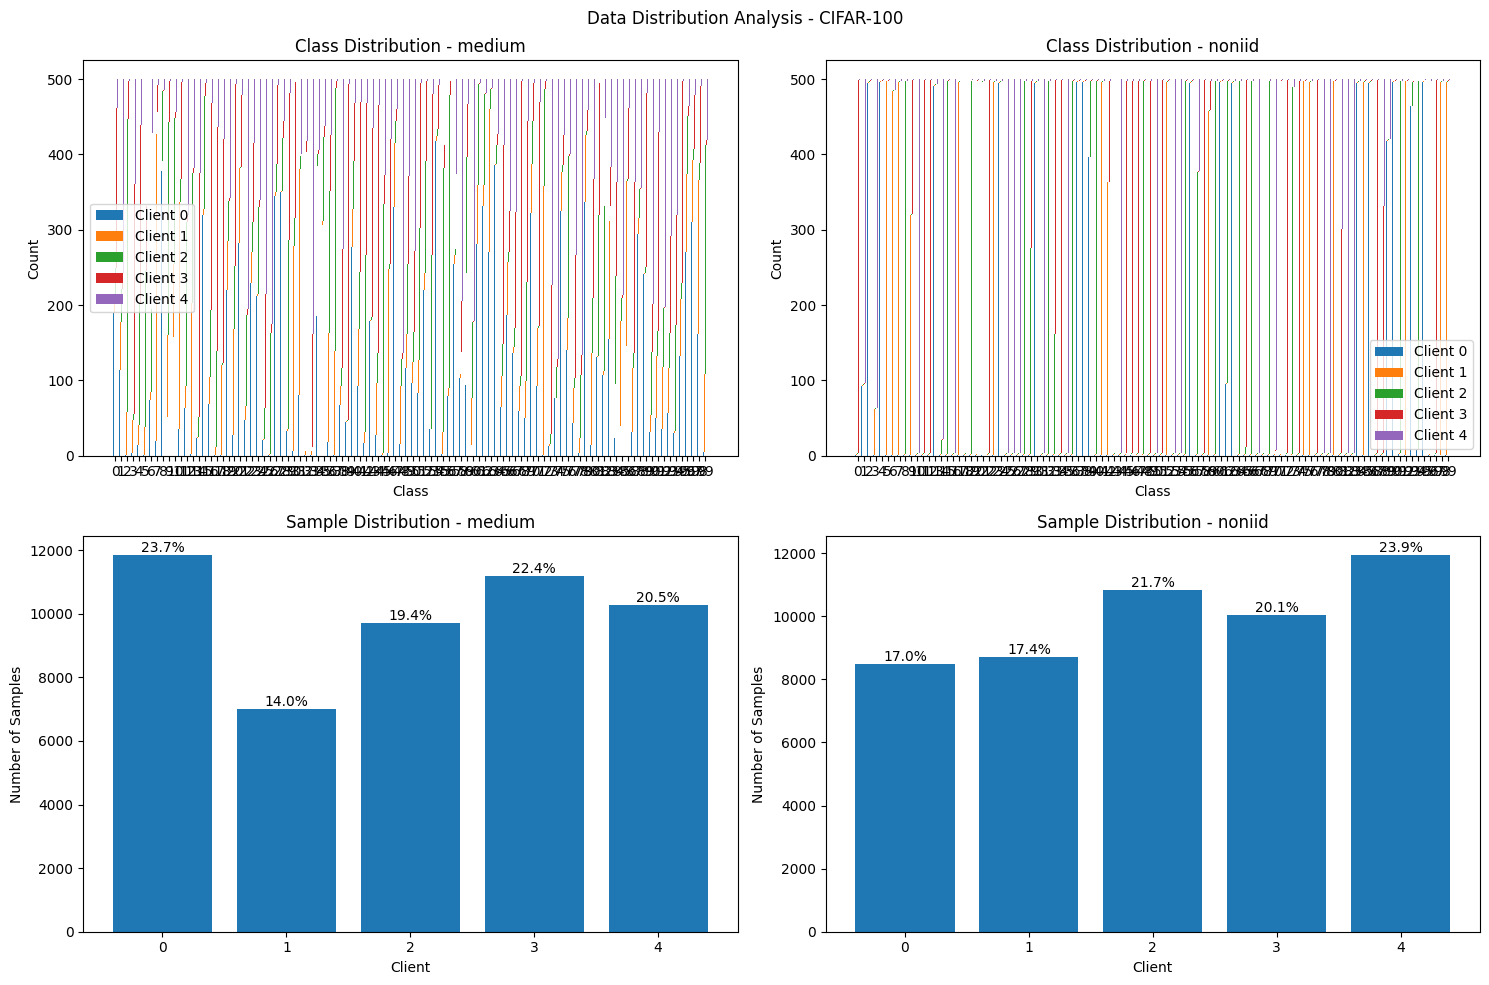

In [6]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "CIFAR-100")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "CIFAR-100")
plt.show()

In [7]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("cifar100")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x00000165FBFFC6D0>
optimizer: {'type': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005}
lr_scheduler: {'type': 'cosine', 'T_max': 100, 'eta_min': 0.0001, 'warmup_epochs': 5, 'warmup_start_lr': 0.001}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
data_augmentation: {'random_crop': True, 'random_horizontal_flip': True, 'random_rotation': 5, 'color_jitter': {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2}}
quantization: {'bits': 8, 'enabled': True}

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 11


In [ ]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    quantization_errors, avg_scale_factors, history = federated_training(
        client_datasets=client_datasets,
        model_name='cifar100',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/cifaaaaar100_5cl_{partition_name}.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        quantization_bits=8,  # Add quantization bits parameter
        save_dir='results',  # Add save directory for logs
        save_interval=1  # Save metrics every round
    )
    
    # Store quantization metrics in history
    history['quantization_errors'] = quantization_errors
    history['avg_scale_factors'] = avg_scale_factors
    
    return model, history

# Update the config to include quantization parameters
config = get_tinyprop_config('cifar100')
config['quantization_bits'] = 8  # Add quantization bits to config

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history,
            'quantization_metrics': {
                'errors': history['quantization_errors'],
                'scale_factors': history['avg_scale_factors']
            }
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue




Starting training for MEDIUM partition...

Training on partition: MEDIUM

Round 1/100
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Batch 5] Debug Info:
  - Loss: 4.6094
  - Loss Change: 0.0000
  - Relative Loss Change: 0.0000
  - Dynamic Threshold: 0.2000
  - Current phi_k: 0.3764
  - Current phi_max: 0.9900
  - Layer Sparsity: 0.5000
  - Skip Ratio: 0.2000
  - Current Skip Ratio: 0.2000
  - Should Skip: False
[Debug][Batch 5] Loss: 4.4907
[Debug][Batch 5] Loss Change: -0.1187
[Debug][Batch 5] Relative Loss Change: 0.0257
[Debug][Batch 5] Phi Update: 0.0974
[Debug][Batch 5] New phi_k: 0.4544
[Debug] phi_k_history: [0.29939536766607355, 0.2984631708823353, 0.37706823900802805, 0.3764229307784502, 0.4543635603670756]

[Batch 10] Debug